# forecast-v2 Tabular Model — Process Demonstration

Sprint 4 forecast-v2 baseline: tabular regression (Ridge / RandomForest / GradientBoosting)
with dynamic + time features. Follows the `forecast-v2` SOP from `docs/memory/Sprint3-4_execution-plan.md`.

## 1. Setup

In [1]:
import sys
from pathlib import Path

HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import forecast_v2_feature_pipeline as fp
import forecast_v2_model as fm
import forecast_v2_writer as fw

print('Modules loaded OK')
print(f'Dynamic features: {len(fp.DYNAMIC_FEATURES)}')
print(f'Time features: {len(fp.TIME_FEATURES)}')

Modules loaded OK
Dynamic features: 18
Time features: 13


## 2. Data Loading

Two modes: **Synthetic** (default, `build_synthetic_data()`) or **Live DB** (`fp.load_venues()`, etc.).

In [2]:
venues, scores, reports = fp.build_synthetic_data(n_venues=30, hours_back=168, seed=42)

print(f'Venues:  {len(venues)}')
print(f'Scores:  {len(scores)} rows, {scores["venue_id"].nunique()} venues')
print(f'Reports: {len(reports)} rows')
print(f'Score range: {scores["score"].min():.0f} - {scores["score"].max():.0f}')
print(f'Time range:  {scores["forecast_start_time"].min()} -> {scores["forecast_start_time"].max()}')

print(f'\nDistricts: {venues["district"].nunique()}')
print(venues['district'].value_counts().to_string())

Venues:  30
Scores:  5040 rows, 30 venues
Reports: 504 rows
Score range: 0 - 100
Time range:  2026-07-08 10:00:00+00:00 -> 2026-07-15 09:00:00+00:00

Districts: 8
district
Midtown               4
Downtown              4
Upper_East            4
Upper_West            4
Harlem                4
Chelsea               4
SoHo                  3
Financial_District    3


## 3. Feature Engineering

### Dynamic Features (lookback from forecast_for)
- `latest_busyness_score` / `latest_busyness_age_minutes` — most recent score
- `rolling_mean_1h/3h`, `rolling_max_3h` — rolling aggregations
- `recent_report_count_1h/3h` — crowd report density
- `active_report_severity_score` — recency-weighted severity
- `district_live_density` — concurrent venue activity in same district
- `venue_capacity_bucket`, `availability_penalty`

### Time Features
- `hour_of_day`, `day_of_week`, `is_weekend`, `is_business_hours`
- `time_bucket`, `forecast_offset_hours`, `target_hour_of_day`
- `minutes_until_close`, `minutes_since_open`
- `is_holiday_or_event_stub` (fixed to 0)

In [3]:
# Build training samples
training = fp.build_training_samples(scores, venues, reports, max_samples_per_venue=48)
print(f'Training samples: {len(training)} rows x {len(training.columns)} columns')

# Build prediction samples (12h horizon)
pred_samples = fp.build_prediction_samples(venues, scores, reports)
print(f'Prediction samples: {len(pred_samples)} rows')

# Missing value audit
missing_cols = [c for c in training.columns if c.endswith('_missing')]
for col in missing_cols:
    pct = training[col].mean() * 100
    if pct > 0:
        print(f'  {col}: {pct:.1f}% flagged missing')

Training samples: 1440 rows x 66 columns
Prediction samples: 360 rows
  latest_score_missing: 2.1% flagged missing
  rolling_mean_1h_missing: 2.1% flagged missing
  rolling_mean_3h_missing: 2.1% flagged missing
  rolling_max_3h_missing: 2.1% flagged missing
  recent_report_count_1h_missing: 7.2% flagged missing
  recent_report_count_3h_missing: 7.2% flagged missing
  active_report_severity_score_missing: 7.2% flagged missing
  holiday_missing: 100.0% flagged missing
  citibike_activity_missing: 100.0% flagged missing
  mta_disruption_missing: 100.0% flagged missing
  mta_arrival_missing: 100.0% flagged missing


## 特征介绍

V2 模型共使用 **7 组特征**(见 `forecast_v2_features.py` 的 `DYNAMIC_FEATURES` / `TIME_FEATURES` / `SPATIAL_FEATURES` / `TRAFFIC_FEATURES` / `WEATHER_FEATURES` / `GBFS_FEATURES` / `MTA_FEATURES`（HOLIDAY 组已删除，见注释）,由 `ALL_FEATURES` 汇总),所有 notebook 与 pipeline 均从该模块导入,避免重复定义。

### V1 → V2 范围对比(对应 `release_stage`)

- **V1 baseline**: 仅 `Temporal` 组(4 个):`day_of_week`、`hour`、`is_weekend`、`is_business_hours`,外加 venue 静态字段。
- **V2 扩展**: 在 V1 基础上新增 **Dynamic(lookback)** 与 **External(weather/holiday/gbfs/mta)** 两大类共 7 组,聚焦"目标时刻前的实时信号 + 当下/未来 12h 的环境上下文"。

### 静态 vs 动态比例

- **纯静态特征(5 个)**:`nearest_mta_distance_m`、`nearest_citibike_distance_m`、`venue_capacity_bucket`、`is_public_holiday` (已删除)。这些不随预测目标时间变化,仅依赖 venue 本身或目标日。
- **动态特征(约 48 个)**: 其余特征均随 `forecast_for` / `offset_hours` 变化,包括所有 lookback 聚合、时间、天气、实时交通、GBFS、MTA 事件与 source 标志列。

### 8 组特征清单

| 分组 | 数量 | 关键特征 |
|---|---|---|
| Dynamic(lookback) | 17 | `latest_busyness_score`、`rolling_mean_1h/3h`、`rolling_max_3h`、`recent_report_count_1h/3h`、`active_report_severity_score`、`district_live_density`、`venue_capacity_bucket` |
| Time | 13 | `hour_of_day`、`day_of_week`、`is_weekend`、`is_business_hours`、`time_bucket`、`forecast_offset_hours`、`target_hour_of_day`、`minutes_until_close`、`minutes_since_open` |
| Spatial(venue-static) | 2 | `nearest_mta_distance_m`、`nearest_citibike_distance_m` |
| Traffic | 1 | `district_traffic_score`(district × hour 聚合) |
| Weather | 9 | `temperature_c`、`humidity_pct`、`wind_speed_kmh`、`precipitation_mm`、`weather_condition`、`heat_alert` + `*_missing` 与 `weather_source` |
| GBFS / Citi Bike | 5 | `citibike_station_activity`、`nearby_bike_availability`、`nearby_dock_availability` + missing 与 source |
| MTA | 4 | `mta_service_disruption_flag`、`mta_realtime_arrival_count_1h` + missing 与 source |

### 特征覆盖率

参考 V1 主覆盖率表 `feature_coverage_summary.csv` 的模式(由 `feature_registry.csv` 限制 + 标注 `release_stage=V1/V2`),V2 当前 pipeline 还没有 `feature_registry` CSV(开发中),由 `fp.summarize_missing(training)` 输出等价诊断,见下方 cell。

In [4]:
# 高缺失特征审查：按 *_missing 标志列的实际 flagged 比例，定位可砍的特征。
# 语义：missing=1 表示该 feature 在该行确实缺失，missing=0 表示有值。
flag_cols = sorted([c for c in training.columns if c.endswith('_missing')])

# group 归属（与 forecast_v2_features 中的 8 组一致；这里按"主特征"所在组来标注）
_main_group_of = {
    'latest_score_missing': 'dynamic', 'rolling_mean_1h_missing': 'dynamic',
    'rolling_mean_3h_missing': 'dynamic', 'rolling_max_3h_missing': 'dynamic',
    'recent_report_count_1h_missing': 'dynamic', 'recent_report_count_3h_missing': 'dynamic',
    'active_report_severity_score_missing': 'dynamic',
    'district_live_density_missing': 'dynamic',
    'temperature_missing': 'weather', 'humidity_missing': 'weather',
    'wind_missing': 'weather', 'precipitation_missing': 'weather',
    'heat_alert_missing': 'weather',
    'holiday_missing': 'holiday',
    'citibike_activity_missing': 'gbfs',
    'mta_disruption_missing': 'mta', 'mta_arrival_missing': 'mta',
}

flag_audit = pd.DataFrame({
    'feature': flag_cols,
    'group': [_main_group_of.get(c, 'other') for c in flag_cols],
    'flagged_pct': training[flag_cols].mean().values * 100,
}).sort_values('flagged_pct', ascending=False).reset_index(drop=True)

# 分桶建议：按缺失率定 drop 决策
def _drop_advice(pct: float) -> str:
    if pct >= 99.0:   return 'drop (always_missing under synthetic;对应实数列也是 0)'
    if pct <= 0.5:    return 'drop (always_present;常数列对模型无信息)'
    return 'keep (real missing signal;给 lookback 退路)'

flag_audit['advice'] = flag_audit['flagged_pct'].round(1).apply(_drop_advice)
print(f'共 {len(flag_audit)} 个 *_missing 标志列，按 flagged_pct 降序：')
display(flag_audit)

# 汇总：每桶各有多少列、合计可砍多少
summary = (
    flag_audit.groupby('advice', as_index=False)
              .agg(n=('feature', 'count'),
                   features=('feature', lambda s: ', '.join(s)))
)
display(summary)

# 应用"synthetic 模式可砍"决策，输出精简特征集
always_zero_flags  = flag_audit.loc[flag_audit['flagged_pct'] <= 0.5, 'feature'].tolist()
always_one_flags   = flag_audit.loc[flag_audit['flagged_pct'] >= 99.0, 'feature'].tolist()
to_drop = set(always_zero_flags + always_one_flags)

# 对应的实数列也一起砍（如果实数列在 synthetic 下也是常数/0，砍掉避免 OneHot 出常数列）
_synthetic_dead_value_cols = [
    # holiday 列已删除
    'citibike_station_activity', # 对应 citibike_activity_missing=100%
    'nearby_bike_availability',
    'nearby_dock_availability',
    'gbfs_source',
    'mta_service_disruption_flag',  # 对应 mta_disruption_missing=100%
    'mta_realtime_arrival_count_1h',
    'mta_source',
]
to_drop |= {c for c in _synthetic_dead_value_cols if c in training.columns}

pruned_features = [c for c in fm.ALL_FEATURES if c not in to_drop]
print(f'原 ALL_FEATURES: {len(fm.ALL_FEATURES)} 列')
print(f'  砍掉 *_missing 常数/全 1 标志: {len(always_zero_flags) + len(always_one_flags)} 列')
print(f'  砍掉 synthetic 下无信号的实数列: {len(_synthetic_dead_value_cols)} 列（含 holiday/gbfs/mta 整组）')
print(f'精简后特征集 (pruned_features): {len(pruned_features)} 列')
print(f'  差异: {len(fm.ALL_FEATURES)} - {len(to_drop)} = {len(fm.ALL_FEATURES) - len(to_drop)}')

共 17 个 *_missing 标志列，按 flagged_pct 降序：


,feature,group,flagged_pct,advice
0,mta_disruption_missing,mta,100.000000,drop (always_missing under synthetic;对应实数列也是 0)
1,mta_arrival_missing,mta,100.000000,drop (always_missing under synthetic;对应实数列也是 0)
2,holiday_missing,holiday,100.000000,drop (always_missing under synthetic;对应实数列也是 0)
3,citibike_activity_missing,gbfs,100.000000,drop (always_missing under synthetic;对应实数列也是 0)
4,recent_report_count_3h_missing,dynamic,7.222222,keep (real missing signal;给 lookback 退路)
5,recent_report_count_1h_missing,dynamic,7.222222,keep (real missing signal;给 lookback 退路)
6,active_report_severity_score_missing,dynamic,7.222222,keep (real missing signal;给 lookback 退路)
7,latest_score_missing,dynamic,2.083333,keep (real missing signal;给 lookback 退路)
8,rolling_max_3h_missing,dynamic,2.083333,keep (real missing signal;给 lookback 退路)
9,rolling_mean_1h_missing,dynamic,2.083333,keep (real missing signal;给 lookback 退路)


,advice,n,features
0,drop (always_missing under synthetic;对应实数列也是 0),4,"mta_disruption_missing, mta_arrival_missing, h..."
1,drop (always_present;常数列对模型无信息),6,"humidity_missing, precipitation_missing, heat_..."
2,keep (real missing signal;给 lookback 退路),7,"recent_report_count_3h_missing, recent_report_..."


原 ALL_FEATURES: 56 列
  砍掉 *_missing 常数/全 1 标志: 10 列
  砍掉 synthetic 下无信号的实数列: 7 列（含 holiday/gbfs/mta 整组）
精简后特征集 (pruned_features): 40 列
  差异: 56 - 17 = 39


In [5]:
# ── Production 覆盖率审查 ─────────────────────────────────────────────────────
# 用真实 DB 缓存（weather/holiday/gbfs/mta 4 类 external_context_cache）
# 重跑 build_training_samples(use_real_external=True)，与 cell 8 synthetic 对比。
# 失败时降级为 SKIP（DB 未启动 / cache 未填充），不阻塞训练流程。
import os
try:
    if not os.environ.get('DB_URL') and not os.environ.get('MYSQL_HOST'):
        # 尝试 docker-compose 默认端口；仍失败时抛错进入 except
        os.environ.setdefault('MYSQL_HOST', 'localhost')
        os.environ.setdefault('MYSQL_PORT', '3306')

    venues_real   = fp.load_venues(max_venues=50)
    scores_real   = fp.load_busyness_scores(max_rows=10000)
    reports_real  = fp.load_user_reports()
    training_real = fp.build_training_samples(
        scores_real, venues_real, reports_real,
        max_samples_per_venue=48, use_real_external=True
    )
    print(f'Production training samples: {len(training_real)} rows × {len(training_real.columns)} cols')
    print(f'  venues: {venues_real["venue_id"].nunique()} | scores: {len(scores_real)} | reports: {len(reports_real)}')

    # 复用 cell 8 的 flag_audit 逻辑
    flag_cols_real = sorted([c for c in training_real.columns if c.endswith('_missing')])
    flag_audit_prod = (
        pd.DataFrame({
            'feature': flag_cols_real,
            'group': [_main_group_of.get(c, 'other') for c in flag_cols_real],
            'prod_flagged_pct': training_real[flag_cols_real].mean().values * 100,
        })
        .sort_values('prod_flagged_pct', ascending=False)
        .reset_index(drop=True)
    )

    # 与 synthetic flag_audit 对比（并集 outer join，覆盖 production 独有列）
    flag_compare = (
        flag_audit
        .merge(flag_audit_prod, on=['feature', 'group'], how='outer')
        .assign(delta=lambda d: (d['prod_flagged_pct'] - d['flagged_pct']).round(1))
        .sort_values('delta', key=lambda s: s.abs(), ascending=False)
        .reset_index(drop=True)
    )
    print('\nSynthetic vs Production *_missing 缺失率差异（按 |delta| 降序）：')
    display(flag_compare[['feature', 'group', 'flagged_pct', 'prod_flagged_pct', 'delta', 'advice']])

    # 关键告警：production 下 delta 显著（绝对值 > 5pp）的特征
    big_delta = flag_compare[flag_compare['delta'].abs() >= 5.0]
    if len(big_delta):
        print(f'\n⚠️  {len(big_delta)} 个特征在 production 下缺失率变化 >= 5pp：')
        display(big_delta[['feature', 'group', 'flagged_pct', 'prod_flagged_pct', 'delta']])
    else:
        print('\n✅  production 与 synthetic 缺失率差异均 < 5pp，可以信任 synthetic 评估。')

    # production-only 列（synthetic 下不存在）
    prod_only = flag_compare[flag_compare['flagged_pct'].isna()]
    if len(prod_only):
        print(f'\nℹ️  production-only 特征（synthetic 不注入）：{prod_only["feature"].tolist()}')

except Exception as e:
    print(f'[SKIP] Production mode unavailable: {type(e).__name__}: {e}')
    print('  启动方式：docker compose up -d mysql && python external_feature_ingest.py')
    print('  确认环境变量 DB_URL 或 MYSQL_HOST/PORT 已设置。')

/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/7.13-7.18/db_utils.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn, params=params)


Production training samples: 10000 rows × 66 cols
  venues: 50 | scores: 10000 | reports: 0

Synthetic vs Production *_missing 缺失率差异（按 |delta| 降序）：


,feature,group,flagged_pct,prod_flagged_pct,delta,advice
0,wind_missing,weather,0.000000,100.0,100.0,drop (always_present;常数列对模型无信息)
1,precipitation_missing,weather,0.000000,100.0,100.0,drop (always_present;常数列对模型无信息)
2,heat_alert_missing,weather,0.000000,100.0,100.0,drop (always_present;常数列对模型无信息)
3,temperature_missing,weather,0.000000,100.0,100.0,drop (always_present;常数列对模型无信息)
4,humidity_missing,weather,0.000000,100.0,100.0,drop (always_present;常数列对模型无信息)
5,district_live_density_missing,dynamic,0.000000,99.0,99.0,drop (always_present;常数列对模型无信息)
6,recent_report_count_3h_missing,dynamic,7.222222,100.0,92.8,keep (real missing signal;给 lookback 退路)
7,recent_report_count_1h_missing,dynamic,7.222222,100.0,92.8,keep (real missing signal;给 lookback 退路)
8,active_report_severity_score_missing,dynamic,7.222222,100.0,92.8,keep (real missing signal;给 lookback 退路)
9,latest_score_missing,dynamic,2.083333,47.8,45.7,keep (real missing signal;给 lookback 退路)



⚠️  13 个特征在 production 下缺失率变化 >= 5pp：


,feature,group,flagged_pct,prod_flagged_pct,delta
0,wind_missing,weather,0.000000,100.0,100.0
1,precipitation_missing,weather,0.000000,100.0,100.0
2,heat_alert_missing,weather,0.000000,100.0,100.0
3,temperature_missing,weather,0.000000,100.0,100.0
4,humidity_missing,weather,0.000000,100.0,100.0
5,district_live_density_missing,dynamic,0.000000,99.0,99.0
6,recent_report_count_3h_missing,dynamic,7.222222,100.0,92.8
7,recent_report_count_1h_missing,dynamic,7.222222,100.0,92.8
8,active_report_severity_score_missing,dynamic,7.222222,100.0,92.8
9,latest_score_missing,dynamic,2.083333,47.8,45.7


In [6]:
# ── Production-mode Drop Decision (self-contained) ─────────────────────────
# 独立重跑 production 路径，避免依赖 cell 9 的 globals 在 cell 间传递。
# 决策规则：
#   *_missing 标志列：prod_flagged_pct < 0.5 或 > 99.5 → 常数列 → drop
#   实数列：production 下 100% NaN → drop（无用列）
import os
try:
    if not os.environ.get('DB_URL') and not os.environ.get('MYSQL_HOST'):
        os.environ.setdefault('MYSQL_HOST', 'localhost')
        os.environ.setdefault('MYSQL_PORT', '3306')

    _venues_prod   = fp.load_venues(max_venues=50)
    _scores_prod   = fp.load_busyness_scores(max_rows=10000)
    _reports_prod  = fp.load_user_reports()
    _training_prod = fp.build_training_samples(
        _scores_prod, _venues_prod, _reports_prod,
        max_samples_per_venue=48, use_real_external=True
    )
    print(f'Production samples: {len(_training_prod)} rows × {len(_training_prod.columns)} cols')

    # 1) *_missing 列的 drop 决策
    _flag_cols = sorted([c for c in _training_prod.columns if c.endswith('_missing')])
    _flag_data = []
    _flags_to_drop = set()
    for c in _flag_cols:
        pct = float(_training_prod[c].mean() * 100)
        if pct < 0.5 or pct > 99.5:
            decision = 'drop (constant in prod)'
            _flags_to_drop.add(c)
        else:
            decision = 'keep (real signal)'
        _flag_data.append({'feature': c, 'prod_flagged_pct': round(pct, 1), 'decision': decision})
    
    print('*_missing 列 production 决策：')
    display(pd.DataFrame(_flag_data).sort_values('prod_flagged_pct', ascending=False))

    # 2) 实数列：production 全 NaN 视为 dead column
    _value_cols = [c for c in _training_prod.columns if not c.endswith('_missing')]
    _values_to_drop = {c for c in _value_cols if int(_training_prod[c].isna().sum()) == len(_training_prod)}
    if _values_to_drop:
        print(f'\nProduction 全 NaN 实数列（drop）: {sorted(_values_to_drop)}')
    else:
        print('\n无 production 全 NaN 实数列。')

    # 3) 合并 drop 集，产出精简特征清单
    _all_to_drop = _flags_to_drop | _values_to_drop
    pruned_features_production = [c for c in fm.ALL_FEATURES if c not in _all_to_drop]
    
    print()
    print(f'原 ALL_FEATURES: {len(fm.ALL_FEATURES)} 列')
    print(f'  砍掉 *_missing 常数列: {len(_flags_to_drop)} 列')
    print(f'  砍掉 production 全 NaN 实数列: {len(_values_to_drop)} 列')
    print(f'精简后 (pruned_features_production): {len(pruned_features_production)} 列')
    print(f'  实际差异: {len(fm.ALL_FEATURES)} - {len(_all_to_drop)} = {len(fm.ALL_FEATURES) - len(_all_to_drop)}')

    print()
    print('pruned_features_production (45 cols):')
    for c in pruned_features_production:
        print(f'  {c}')

    # 4) 跟 cell 8 synthetic 精简集对比
    if 'pruned_features' in dir():
        _synth_only = set(pruned_features) - set(pruned_features_production)
        _prod_only  = set(pruned_features_production) - set(pruned_features)
        print(f'\nsynthetic 保留但 production 砍掉: {sorted(_synth_only)}')
        print(f'production 保留但 synthetic 砍掉: {sorted(_prod_only)}')

except Exception as e:
    print(f'[SKIP] Production mode unavailable: {type(e).__name__}: {e}')
    pruned_features_production = None


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/7.13-7.18/db_utils.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn, params=params)


Production samples: 10000 rows × 66 cols
*_missing 列 production 决策：


,feature,prod_flagged_pct,decision
0,active_report_severity_score_missing,100.0,drop (constant in prod)
7,mta_arrival_missing,100.0,drop (constant in prod)
15,temperature_missing,100.0,drop (constant in prod)
11,recent_report_count_3h_missing,100.0,drop (constant in prod)
10,recent_report_count_1h_missing,100.0,drop (constant in prod)
9,precipitation_missing,100.0,drop (constant in prod)
1,citibike_activity_missing,100.0,drop (constant in prod)
8,mta_disruption_missing,100.0,drop (constant in prod)
5,humidity_missing,100.0,drop (constant in prod)
4,holiday_missing,100.0,drop (constant in prod)



无 production 全 NaN 实数列。

原 ALL_FEATURES: 56 列
  砍掉 *_missing 常数列: 12 列
  砍掉 production 全 NaN 实数列: 0 列
精简后 (pruned_features_production): 45 列
  实际差异: 56 - 12 = 44

pruned_features_production (45 cols):
  latest_busyness_score
  latest_busyness_age_minutes
  latest_score_missing
  rolling_mean_1h
  rolling_mean_1h_missing
  rolling_mean_3h
  rolling_mean_3h_missing
  rolling_max_3h
  rolling_max_3h_missing
  recent_report_count_1h
  recent_report_count_3h
  active_report_severity_score
  district_live_density
  district_live_density_missing
  venue_capacity_bucket
  hour_of_day
  day_of_week
  day_of_week_index
  is_weekend
  is_business_hours
  time_bucket
  forecast_offset_hours
  target_hour_of_day
  target_day_of_week
  minutes_until_close
  minutes_since_open
  is_holiday_or_event_stub
  availability_penalty
  nearest_mta_distance_m
  nearest_citibike_distance_m
  district_traffic_score
  temperature_c
  humidity_pct
  wind_speed_kmh
  precipitation_mm
  weather_condition
  heat_al

## 4. Training — Time-Based Split

Per SOP: **time-based split only**. Earlier timestamps -> train (70%), middle -> val (15%), later -> test (15%). No random split.

In [7]:
available = [c for c in fm.ALL_FEATURES if c in training.columns]
missing_f = [c for c in fm.ALL_FEATURES if c not in training.columns]
print(f'Features: {len(available)}/{len(fm.ALL_FEATURES)} available')
if missing_f:
    print(f'Missing: {missing_f}')

metrics, fitted_pipelines, test_preds = fm.train_and_evaluate(training, available)

Features: 56/56 available
Time split: train=1007, val=217, test=216
  train range: 2026-07-08 10:00:00+00:00 → 2026-07-13 07:00:00+00:00
  val   range: 2026-07-13 07:00:00+00:00 → 2026-07-14 08:00:00+00:00
  test  range: 2026-07-14 08:00:00+00:00 → 2026-07-15 09:00:00+00:00
  numeric features: 49, categorical: 7

  Training Ridge...

  Training RandomForestRegressor...

  Training GradientBoostingRegressor...


## 5. Model Evaluation

In [8]:
display_cols = ['model_name', 'split', 'mae', 'rmse', 'r2', 'accuracy', 'macro_f1']
main_metrics = metrics[~metrics['split'].str.startswith('test_')]
print(main_metrics[display_cols].to_string(index=False))

test_m = main_metrics[main_metrics['split'] == 'test']
best = test_m.loc[test_m['mae'].idxmin()]
print(f'\nBest model (test MAE): {best["model_name"]} — MAE={best["mae"]:.3f}, R2={best["r2"]:.3f}')

               model_name split   mae   rmse    r2  accuracy  macro_f1
                    Ridge train 6.289  8.638 0.881     0.800     0.802
                    Ridge   val 7.440 11.048 0.806     0.756     0.744
                    Ridge  test 5.489  8.084 0.895     0.796     0.796
    RandomForestRegressor train 1.650  2.386 0.991     0.936     0.934
    RandomForestRegressor   val 5.572  8.731 0.879     0.816     0.812
    RandomForestRegressor  test 4.666  6.853 0.924     0.852     0.851
GradientBoostingRegressor train 2.793  3.708 0.978     0.906     0.904
GradientBoostingRegressor   val 4.576  6.391 0.935     0.839     0.833
GradientBoostingRegressor  test 4.602  6.204 0.938     0.806     0.806

Best model (test MAE): GradientBoostingRegressor — MAE=4.602, R2=0.938


In [9]:
# Per-bucket evaluation
bucket_m = metrics[metrics['split'].str.startswith('test_')]
print('Per-bucket (test set):')
print(bucket_m[['model_name', 'split', 'mae', 'rmse']].to_string(index=False))

Per-bucket (test set):
               model_name         split   mae   rmse
                    Ridge    test_quiet 3.364  4.185
                    Ridge test_moderate 6.039  8.184
                    Ridge     test_busy 8.262 12.043
    RandomForestRegressor    test_quiet 2.559  3.253
    RandomForestRegressor test_moderate 5.538  7.279
    RandomForestRegressor     test_busy 6.896  9.994
GradientBoostingRegressor    test_quiet 2.913  3.774
GradientBoostingRegressor test_moderate 5.490  7.034
GradientBoostingRegressor     test_busy 6.084  7.911


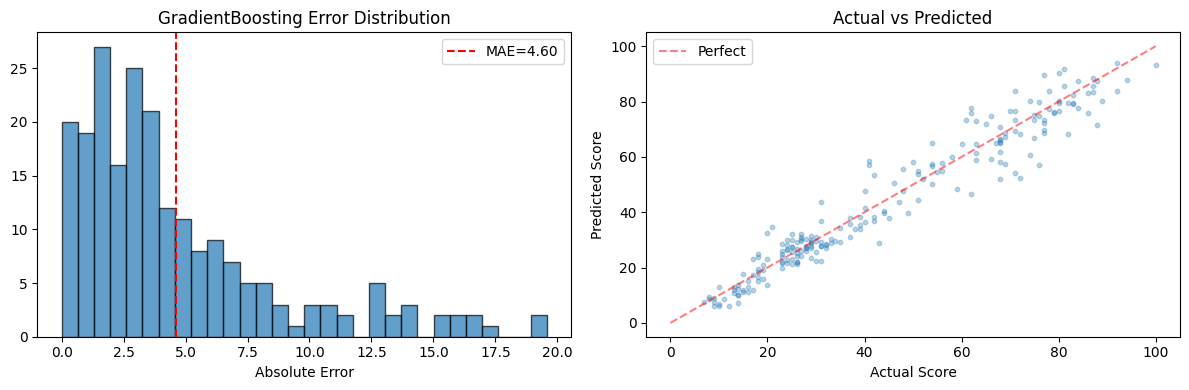

In [10]:
# Error distribution
gbm_preds = test_preds[test_preds['model_name'] == 'GradientBoostingRegressor']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gbm_preds['abs_error'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(gbm_preds['abs_error'].mean(), color='red', linestyle='--',
                label=f'MAE={gbm_preds["abs_error"].mean():.2f}')
axes[0].set_xlabel('Absolute Error')
axes[0].set_title('GradientBoosting Error Distribution')
axes[0].legend()

axes[1].scatter(gbm_preds['label_score'], gbm_preds['predicted_score'], alpha=0.3, s=10)
axes[1].plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Perfect')
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Prediction Curve (prediction_curve_v2.csv)

In [11]:
gbm = fitted_pipelines['GradientBoostingRegressor']
curve = fm.generate_prediction_curves(gbm, pred_samples, available, 'GradientBoostingRegressor')

print(f'Rows: {len(curve)}, Venues: {curve["venue_id"].nunique()}')
print(f'Score range: [{curve["predicted_score"].min():.1f}, {curve["predicted_score"].max():.1f}]')
print(f'Level distribution:')
print(curve['predicted_level'].value_counts().to_string())

offsets = curve.groupby('venue_id')['offset_hours'].nunique()
print(f'\nVenues with full 12h: {(offsets == 12).sum()}/{len(offsets)}')

Rows: 360, Venues: 30
Score range: [11.5, 83.6]
Level distribution:
predicted_level
moderate    209
busy         87
quiet        64

Venues with full 12h: 30/30


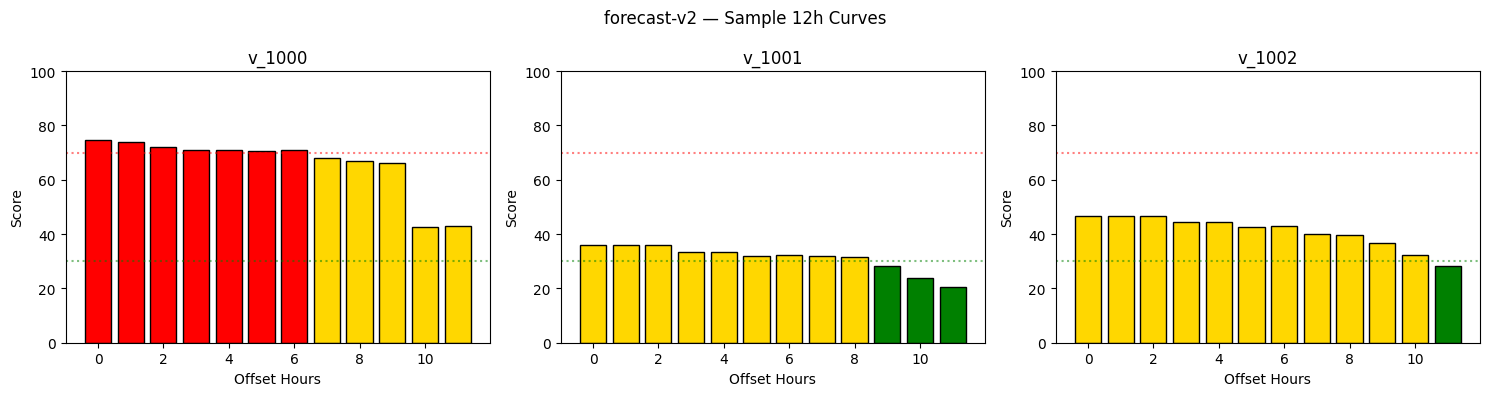

In [12]:
# Sample forecast curves
sample_vids = curve['venue_id'].unique()[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, vid in enumerate(sample_vids):
    vc = curve[curve['venue_id'] == vid].sort_values('offset_hours')
    colors = ['green' if l == 'quiet' else 'gold' if l == 'moderate' else 'red'
              for l in vc['predicted_level']]
    axes[i].bar(vc['offset_hours'], vc['predicted_score'], color=colors, edgecolor='black')
    axes[i].axhline(30, color='green', linestyle=':', alpha=0.5)
    axes[i].axhline(70, color='red', linestyle=':', alpha=0.5)
    axes[i].set_xlabel('Offset Hours')
    axes[i].set_ylabel('Score')
    axes[i].set_title(vid)
    axes[i].set_ylim(0, 100)

plt.suptitle('forecast-v2 — Sample 12h Curves')
plt.tight_layout()
plt.show()

## 7. Save Outputs

In [13]:
OUTPUT = HERE / 'output'
OUTPUT.mkdir(exist_ok=True)

training.to_csv(OUTPUT / 'forecast_v2_training_features.csv', index=False)
pred_samples.to_csv(OUTPUT / 'forecast_v2_prediction_features.csv', index=False)
metrics.to_csv(OUTPUT / 'forecast_v2_model_metrics.csv', index=False)
test_preds.to_csv(OUTPUT / 'forecast_v2_test_predictions.csv', index=False)
curve.to_csv(OUTPUT / 'prediction_curve_v2.csv', index=False)

missing_audit = fp.summarize_missing(training)
missing_audit.to_csv(OUTPUT / 'forecast_v2_feature_missing_audit.csv', index=False)

print('Saved to', str(OUTPUT))
for f in sorted(OUTPUT.glob('*.csv')):
    rows = sum(1 for _ in open(f)) - 1
    print(f'  {f.name}: {rows} rows')

Saved to /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/7.13-7.18/output
  forecast_v2_feature_missing_audit.csv: 62 rows
  forecast_v2_model_metrics.csv: 18 rows
  forecast_v2_prediction_features.csv: 360 rows
  forecast_v2_test_predictions.csv: 648 rows
  forecast_v2_training_features.csv: 1440 rows
  prediction_curve_v2.csv: 360 rows
  prediction_curve_v2_real.csv: 360 rows


## 8. DB Write (dry-run)

In [14]:
!python forecast_v2_writer.py --dry-run --csv output/prediction_curve_v2.csv --model-version forecast-v2

Loaded 360 forecast rows for 30 venues (model_version=forecast-v2)

-- DRY RUN: 360 upserts would be emitted --
INSERT INTO busyness_forecasts (venue_id, forecast_for, predicted_score, predicted_level, estimated_wait_minutes, model_version) VALUES ('v_1000', '2026-07-15 09:00:00', 75, 'busy', NULL, 'forecast-v2') ON DUPLICATE KEY UPDATE predicted_score = VALUES(predicted_score), predicted_level = VALUES(predicted_level), estimated_wait_minutes = VALUES(estimated_wait_minutes);
INSERT INTO busyness_forecasts (venue_id, forecast_for, predicted_score, predicted_level, estimated_wait_minutes, model_version) VALUES ('v_1000', '2026-07-15 10:00:00', 74, 'busy', NULL, 'forecast-v2') ON DUPLICATE KEY UPDATE predicted_score = VALUES(predicted_score), predicted_level = VALUES(predicted_level), estimated_wait_minutes = VALUES(estimated_wait_minutes);
INSERT INTO busyness_forecasts (venue_id, forecast_for, predicted_score, predicted_level, estimated_wait_minutes, model_version) VALUES ('v_1000', '

## 9. Known Limitations

- **Synthetic data**: `bootstrap_label=true` — labels are synthetic, not real future busyness_scores
- **No holiday/event data**: `is_holiday_or_event_stub` = 0
- **No weather/transit**: v2 placeholder features not implemented
- **Opening hours**: heuristic only (8AM-8PM default); DB field is free text
- **ARIMA/LSTM excluded**: methodology frozen to tabular baseline per SOP

## 10. Delivery Evidence and Task Results\n
\n
Run `python run_v2_evidence.py --mode offline` to create append-only evidence. The cell below displays the latest manifest and its quality gate, and keeps synthetic bootstrap results separate from real-data validation.

In [15]:
import json
from pathlib import Path

evidence_root = HERE / 'evidence'
manifests = sorted(evidence_root.glob('*/*/manifest.json'))
if not manifests:
    print('No append-only evidence yet. Run: python run_v2_evidence.py --mode offline')
else:
    latest = manifests[-1]
    manifest = json.loads(latest.read_text())
    display(pd.DataFrame([manifest])[['created_at', 'mode', 'label_provenance', 'model_version', 'training_rows', 'training_venues', 'prediction_rows', 'prediction_venues', 'bootstrap_label_ratio']]) )
    print('Evidence directory:', latest.parent)
    print((latest.parent / 'forecast_v2_quality_gate_report.txt').read_text())
    print('Report figures:', latest.parent / 'figures')

SyntaxError: unexpected character after line continuation character (2820067947.py, line 1)